<a href="https://colab.research.google.com/github/vignesh-1213/Loan-Approval-Prediction/blob/main/Copy_of_loan_prediction_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction
This notebook covers the full end-to-end process of building a machine learning model for loan approval prediction.

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [ ]:
try:
    df = pd.read_csv('loan_prediction.csv')
except FileNotFoundError:
    # Fallback for Google Colab
    df = pd.read_csv('https://raw.githubusercontent.com/vignesh-1213/Loan-Approval-Prediction/main/loan_prediction.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Exploratory Data Analysis & Preprocessing

In [ ]:
print(df.isnull().sum())

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [ ]:
# Drop Loan_ID
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

# Impute missing values
cat_cols_missing = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for col in cat_cols_missing:
    df[col] = df[col].fillna(df[col].mode()[0])

num_cols_missing = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
for col in num_cols_missing:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Encoding Dependents (3+ to 3)
df['Dependents'] = df['Dependents'].astype(str).str.replace('+', '').astype(int)

# Encoding Categorical Variables
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Target Encoding
df['Loan_Status'] = df['Loan_Status'].map({'N': 0, 'Y': 1})

## 4. Train-Test Split & Scaling

In [ ]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Handle Class Imbalance with SMOTE

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Loan_Status
1    337
0    154
Name: count, dtype: int64

After SMOTE:
Loan_Status
1    337
0    337
Name: count, dtype: int64


## 6. Model Training and Comparison

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.852273,0.882353,0.867052,0.870279
1,Random Forest,0.850575,0.870588,0.860465,0.789783
2,Gradient Boosting,0.820225,0.858824,0.839080,0.779102


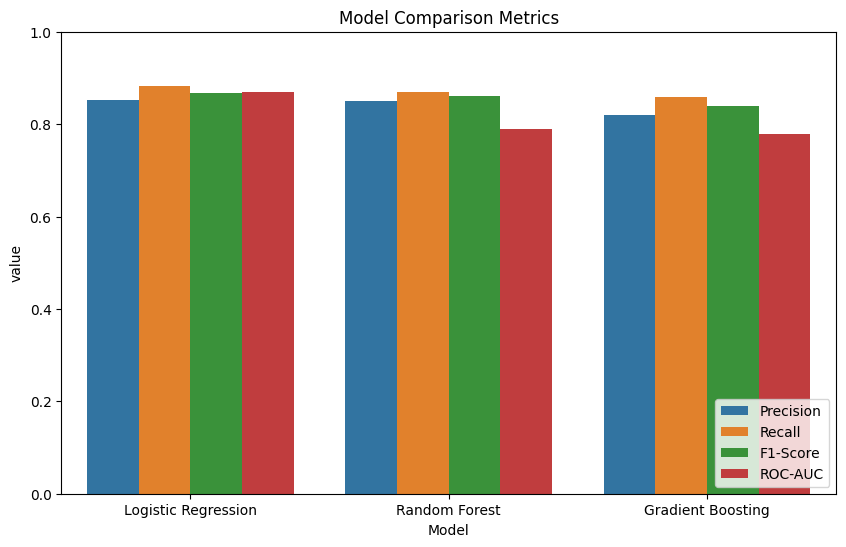

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.melt(id_vars='Model'), x='Model', y='value', hue='variable')
plt.title('Model Comparison Metrics')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()